# Laboratory Exercise: Predicting Champion Picks in the LoL Worlds Final

**Goal:** In this laboratory exercise, you will build a machine learning model capable of predicting whether a League of Legends champion will be selected for the **Season 13 Worlds Final**.
Using detailed performance statistics from **Season 12** and **Season 13**, you will explore, clean, and merge the datasets, construct meaningful features, analyze champion trends, and ultimately train a classification model that identifies which champions are strong enough to appear on the world stage.


## 1. Overview of the Task

You are given two datasets:

- `season_12_data.csv`
- `season_13_data.csv`

Each dataset contains the following features:

- **Name**
  The name of the champion (e.g., *Ahri*, *Garen*, *Lee Sin*).

- **Class**
  The gameplay class or archetype of the champion.
  Possible values include: **Fighter**, **Assassin**, **Mage**, **Marksman**, **Support**, **Tank**.

- **Role**
  The primary lane or position where the champion is played.
  Possible roles: **Top**, **Mid**, **ADC**, **Support**, **Jungle**.

- **Tier**
  The overall performance/strength ranking of the champion for that season.
  Possible tiers: **S+**, **S**, **A**, **B**, **C**, **D**.

- **Trend**
  The performance trend or momentum indicator (e.g., positive/negative score trend across the season).

- **Win %**
  The win rate percentage of the champion in the given role and season (e.g., `51%`).

- **Role %**
  The percentage of games in which this champion is played in the **given role** (e.g., a champion being played top lane 80% of the time).

- **Pick %**
  The pick rate percentage, i.e., how often the champion is selected overall.

- **Ban %**
  The ban rate percentage.
  - This is split by side, e.g., `"Blue (23%) / Red (34%)"`, indicating separate ban rates depending on the team side.

- **KDA**
  The Kill/Death ratio of the champion for the season.

Your final objective is to build a machine learning model that predicts whether a champion will be selected for the **Season 13 Worlds Final** (fictionally played every two seasons).

To achieve this, you will build a complete data-science pipeline:
- Data loading
- Column renaming
- Full outer merging
- Data cleaning (strings, percentages, KDA formatting)
- Handling missing values
- Exploratory Data Analysis (EDA)
- Feature selection
- Categorical encoding
- Target variable creation
- Train–test splitting
- ML model training
- Final evaluation

## 2. Renaming Columns by Season

Both datasets share identical column names.
To avoid confusion after merging, rename all non-key columns so that their season is clearly indicated.

Keep the following **unchanged**:
- `Name`
- `Role`

Rename all other columns using this format:

- `Win % (season 12)`
- `Win % (season 13)`

This ensures clarity and prevents accidental overwriting during merging or preprocessing.

## 3. Full Outer Join on `Name` and `Role`

Perform a **full outer merge** between the two datasets using:

- `Name`
- `Role`

Why full outer join?:
- Some champions exist in Season 13 but not in Season 12 (new releases)
- Some champions exist in Season 12 but only in certain roles, resulting in partial feature availability

A full outer join ensures:
- Champions appearing only in Season 12 are included
- Champions appearing only in Season 13 are included
- Shared champions receive both seasons’ features
- Missing values naturally appear where data is unavailable

After merging:
- Inspect the shape
- Check for missing values
- Show initial descriptive statistics

How to perform the merge:

- `df_full = season12.merge(season13, on=["Name","Role"], how="outer")`

## 4. Cleaning Numeric-Like Columns Stored as Strings

Several columns appear numeric but are actually stored as strings. These must be converted into clean, consistent numerical values before any modeling or missing-value handling.

Examples of problematic formats:

- `"78%"` → should become `78.0`
- `"Blue (23%)/Red (34%)"` → Ban rate split by side

### Your tasks:

1. **Strip percentage symbols (`%`)** from all percentage columns.
2. **Handle the Ban % special case**.
   - The `Ban %` column contains values such as: `"Blue (23%)/Red (34%)"`
   - Take the **sum** of them: `sum(23, 34)`
3. **Convert all cleaned values to `float`**
4. Ensure that all missing values stay **`NaN`**

This preprocessing step must be completed **before handling missing values**

## 5. Handling Missing Values

You must:

- Analyze why values are missing
- Apply appropriate techniques:
  - **Simple Imputation (mean, mode, median)**
  - **Advanced Imputation (MICE, KNN)**
  - **Dropping rows/columns** when justified

Your decisions must be motivated.

## 6. Exploratory Data Analysis (EDA)

Perform EDA to understand data patterns, distributions, and relationships.

Suggested visualizations:

- Distribution plots (histograms)
- Boxplots for numeric columns
- Correlation heatmap (numeric features)
- Role distribution (Season 12 & 13)
- Tier distribution
- Missing-value visualization heatmap

Use visualizations to justify feature selection and preprocessing choices.

## 7. Feature Selection

Not all features are equally valuable.
You must determine:

- Which numeric features matter most
- Which categorical features are useful
- Whether any columns are redundant or irrelevant

## 8. Creating the Target Column: `World Cup Suitable`

Create a new binary label based on Tier performance:

### A champion is labeled **1 (World Cup Suitable)** if:

- `Tier (season 12)` is **S+**,
  **OR**
- `Tier (season 13)` is **S** or **S+**

Otherwise → label **0**.

This new column will be your **prediction target**.

After generating the label:

- Decide whether to drop or encode the Tier columns
- Ensure proper categorical encoding if kept

## 9. Encoding Categorical Features

Choose the encoding strategy:

- **One-Hot Encoding**
- **Ordinal Encoding**

## 10. Train–Test Split

Split your dataset into:

- **Training set** (80%)
- **Test set** (20%)

## 11. Model Training

Train at least one classification model

## 12. Model Evaluation

Evaluate your model using classification metrics

In [146]:
import pandas as pd

In [147]:
df1=pd.read_csv('season_12_data.csv')
df2=pd.read_csv('season_13_data.csv')

In [148]:
df1.head()

,Name,Class,Role,Tier,Trend,Win %,Role %,Pick %,Ban %,KDA
0,Aatrox,Fighter,TOP,A,6.52,49.97%,94.62%,4.43%,Blue (0.83%)/Red (1.2%),1.97
1,Ahri,Mage,MID,A,-0.24,49.93%,93.47%,4.62%,Blue (0.2%)/Red (0.84%),2.56
2,Akali,Assassin,MID,S,6.51,48.59%,65.65%,8.16%,Blue (6.51%)/Red (6.37%),2.34
3,Akali,Assassin,TOP,A,3.34,48.57%,34.06%,4.24%,Blue (5.57%)/Red (7.31%),2.04
4,Akshan,Marksman,MID,S,0.65,51.46%,58.01%,4.83%,Blue (5.07%)/Red (16.84%),2.23


In [149]:
df2.head()

,Name,Class,Role,Tier,Trend,Win %,Role %,Pick %,Ban %,KDA
0,Aatrox,Fighter,TOP,S,-31.86,47.68%,91.63%,6.62%,Blue (9.8%)/Red (2.18%),1.77
1,Ahri,Mage,MID,S,4.55,49.50%,94.65%,5.81%,Blue (1.54%)/Red (0.19%),2.58
2,Akali,Assassin,MID,S,4.33,48.41%,75.74%,8.11%,Blue (5.74%)/Red (7.28%),2.37
3,Akali,Assassin,TOP,C,-1.51,45.92%,23.50%,2.55%,Blue (0.47%)/Red (12.55%),2.00
4,Akshan,Marksman,MID,A,0.34,51.62%,66.03%,2.75%,Blue (0.06%)/Red (3.73%),2.26


In [150]:
df1_new_names=[f"{col} (season 12)" if col!='Role' and col!='Name' else col for col in df1.columns]
df1_new_names

['Name',
 'Class (season 12)',
 'Role',
 'Tier (season 12)',
 'Trend (season 12)',
 'Win % (season 12)',
 'Role % (season 12)',
 'Pick % (season 12)',
 'Ban % (season 12)',
 'KDA (season 12)']

In [151]:
df1.columns=df1_new_names

In [152]:
df1.head()

,Name,Class (season 12),Role,Tier (season 12),Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12)
0,Aatrox,Fighter,TOP,A,6.52,49.97%,94.62%,4.43%,Blue (0.83%)/Red (1.2%),1.97
1,Ahri,Mage,MID,A,-0.24,49.93%,93.47%,4.62%,Blue (0.2%)/Red (0.84%),2.56
2,Akali,Assassin,MID,S,6.51,48.59%,65.65%,8.16%,Blue (6.51%)/Red (6.37%),2.34
3,Akali,Assassin,TOP,A,3.34,48.57%,34.06%,4.24%,Blue (5.57%)/Red (7.31%),2.04
4,Akshan,Marksman,MID,S,0.65,51.46%,58.01%,4.83%,Blue (5.07%)/Red (16.84%),2.23


In [153]:
df2_new_names=[f"{col} (season 13)" if col!='Role' and col!='Name' else col for col in df2.columns]
df2.columns=df2_new_names

In [154]:
df2.head()

,Name,Class (season 13),Role,Tier (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13)
0,Aatrox,Fighter,TOP,S,-31.86,47.68%,91.63%,6.62%,Blue (9.8%)/Red (2.18%),1.77
1,Ahri,Mage,MID,S,4.55,49.50%,94.65%,5.81%,Blue (1.54%)/Red (0.19%),2.58
2,Akali,Assassin,MID,S,4.33,48.41%,75.74%,8.11%,Blue (5.74%)/Red (7.28%),2.37
3,Akali,Assassin,TOP,C,-1.51,45.92%,23.50%,2.55%,Blue (0.47%)/Red (12.55%),2.00
4,Akshan,Marksman,MID,A,0.34,51.62%,66.03%,2.75%,Blue (0.06%)/Red (3.73%),2.26


In [155]:
df_full = df1.merge(df2, on=["Name","Role"], how="outer")

In [156]:
df_full.shape

(258, 18)

In [157]:
df=df_full

In [158]:
df.head()

,Name,Class (season 12),Role,Tier (season 12),Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Tier (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13)
0,Aatrox,Fighter,TOP,A,6.52,49.97%,94.62%,4.43%,Blue (0.83%)/Red (1.2%),1.97,Fighter,S,-31.86,47.68%,91.63%,6.62%,Blue (9.8%)/Red (2.18%),1.77
1,Ahri,Mage,MID,A,-0.24,49.93%,93.47%,4.62%,Blue (0.2%)/Red (0.84%),2.56,Mage,S,4.55,49.50%,94.65%,5.81%,Blue (1.54%)/Red (0.19%),2.58
2,Akali,Assassin,MID,S,6.51,48.59%,65.65%,8.16%,Blue (6.51%)/Red (6.37%),2.34,Assassin,S,4.33,48.41%,75.74%,8.11%,Blue (5.74%)/Red (7.28%),2.37
3,Akali,Assassin,TOP,A,3.34,48.57%,34.06%,4.24%,Blue (5.57%)/Red (7.31%),2.04,Assassin,C,-1.51,45.92%,23.50%,2.55%,Blue (0.47%)/Red (12.55%),2.00
4,Akshan,Marksman,MID,S,0.65,51.46%,58.01%,4.83%,Blue (5.07%)/Red (16.84%),2.23,Marksman,A,0.34,51.62%,66.03%,2.75%,Blue (0.06%)/Red (3.73%),2.26


In [159]:
import regex as re

In [160]:
def perprocess_percentages(value):
    if not pd.isna(value):
        val=re.findall(r"\d+\.?\d+",value)
        return float(val[0])

In [161]:
df['Win % (season 12)'].unique()

array(['49.97%', '49.93%', '48.59%', '48.57%', '51.46%', '51.58%',
       '49.92%', '50.27%', '50.09%', '51.97%', '47.66%', '52.45%', nan,
       '47.36%', '49.66%', '50.81%', '46.67%', '50.23%', '51.87%',
       '51.68%', '49.18%', '50.73%', '50.20%', '50.30%', '49.47%',
       '49.57%', '52.82%', '49.38%', '50.37%', '52.62%', '51.76%',
       '50.52%', '49.91%', '49.67%', '49.48%', '49.64%', '49.28%',
       '50.54%', '50.05%', '50.83%', '50.38%', '48.87%', '48.67%',
       '51.55%', '49.86%', '48.00%', '47.64%', '48.75%', '49.10%',
       '51.35%', '49.82%', '51.18%', '49.85%', '49.16%', '48.24%',
       '48.09%', '50.56%', '51.04%', '49.40%', '50.68%', '48.62%',
       '49.44%', '51.03%', '51.32%', '49.03%', '48.91%', '54.98%',
       '49.39%', '52.58%', '51.42%', '49.59%', '50.63%', '50.71%',
       '49.95%', '50.17%', '50.47%', '55.14%', '50.36%', '52.79%',
       '48.85%', '48.45%', '49.61%', '49.35%', '49.20%', '50.65%',
       '49.26%', '50.84%', '51.08%', '50.26%', '50.49%', 

In [162]:
df['Win % (season 12)']=df['Win % (season 12)'].apply(perprocess_percentages)

In [163]:
df.head()

,Name,Class (season 12),Role,Tier (season 12),Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Tier (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13)
0,Aatrox,Fighter,TOP,A,6.52,49.97,94.62%,4.43%,Blue (0.83%)/Red (1.2%),1.97,Fighter,S,-31.86,47.68%,91.63%,6.62%,Blue (9.8%)/Red (2.18%),1.77
1,Ahri,Mage,MID,A,-0.24,49.93,93.47%,4.62%,Blue (0.2%)/Red (0.84%),2.56,Mage,S,4.55,49.50%,94.65%,5.81%,Blue (1.54%)/Red (0.19%),2.58
2,Akali,Assassin,MID,S,6.51,48.59,65.65%,8.16%,Blue (6.51%)/Red (6.37%),2.34,Assassin,S,4.33,48.41%,75.74%,8.11%,Blue (5.74%)/Red (7.28%),2.37
3,Akali,Assassin,TOP,A,3.34,48.57,34.06%,4.24%,Blue (5.57%)/Red (7.31%),2.04,Assassin,C,-1.51,45.92%,23.50%,2.55%,Blue (0.47%)/Red (12.55%),2.00
4,Akshan,Marksman,MID,S,0.65,51.46,58.01%,4.83%,Blue (5.07%)/Red (16.84%),2.23,Marksman,A,0.34,51.62%,66.03%,2.75%,Blue (0.06%)/Red (3.73%),2.26


In [57]:
df['Role % (season 12)']=df['Role % (season 12)'].apply(perprocess_percentages)
df['Pick % (season 12)']=df['Pick % (season 12)'].apply(perprocess_percentages)
df['Win % (season 13)']=df['Win % (season 13)'].apply(perprocess_percentages)
df['Role % (season 13)']=df['Role % (season 13)'].apply(perprocess_percentages)
df['Pick % (season 13)']=df['Pick % (season 13)'].apply(perprocess_percentages)

In [58]:
df.head()

,Name,Class (season 12),Role,Tier (season 12),Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Tier (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13)
0,Aatrox,Fighter,TOP,A,6.52,49.97,94.62,4.43,Blue (0.83%)/Red (1.2%),1.97,Fighter,S,-31.86,47.68,91.63,6.62,Blue (9.8%)/Red (2.18%),1.77
1,Ahri,Mage,MID,A,-0.24,49.93,93.47,4.62,Blue (0.2%)/Red (0.84%),2.56,Mage,S,4.55,49.50,94.65,5.81,Blue (1.54%)/Red (0.19%),2.58
2,Akali,Assassin,MID,S,6.51,48.59,65.65,8.16,Blue (6.51%)/Red (6.37%),2.34,Assassin,S,4.33,48.41,75.74,8.11,Blue (5.74%)/Red (7.28%),2.37
3,Akali,Assassin,TOP,A,3.34,48.57,34.06,4.24,Blue (5.57%)/Red (7.31%),2.04,Assassin,C,-1.51,45.92,23.50,2.55,Blue (0.47%)/Red (12.55%),2.00
4,Akshan,Marksman,MID,S,0.65,51.46,58.01,4.83,Blue (5.07%)/Red (16.84%),2.23,Marksman,A,0.34,51.62,66.03,2.75,Blue (0.06%)/Red (3.73%),2.26


In [59]:
def preprocess_ban(value):
    if not pd.isna(value):
        val1,val2=value.split("/")
        inside1 = re.findall(r"\((.*?)\)", val1)[0]
        perc1=re.findall(r"\d+(?:\.\d+)?",inside1)[0]
        inside2 = re.findall(r"\((.*?)\)", val2)[0]
        perc2=re.findall(r"\d+(?:\.\d+)?",inside2)[0]
        return float(perc1)+float(perc2)

In [60]:
df['Ban % (season 12)']=df['Ban % (season 12)'].apply(preprocess_ban)

In [61]:
df.head()

,Name,Class (season 12),Role,Tier (season 12),Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Tier (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13)
0,Aatrox,Fighter,TOP,A,6.52,49.97,94.62,4.43,2.03,1.97,Fighter,S,-31.86,47.68,91.63,6.62,Blue (9.8%)/Red (2.18%),1.77
1,Ahri,Mage,MID,A,-0.24,49.93,93.47,4.62,1.04,2.56,Mage,S,4.55,49.50,94.65,5.81,Blue (1.54%)/Red (0.19%),2.58
2,Akali,Assassin,MID,S,6.51,48.59,65.65,8.16,12.88,2.34,Assassin,S,4.33,48.41,75.74,8.11,Blue (5.74%)/Red (7.28%),2.37
3,Akali,Assassin,TOP,A,3.34,48.57,34.06,4.24,12.88,2.04,Assassin,C,-1.51,45.92,23.50,2.55,Blue (0.47%)/Red (12.55%),2.00
4,Akshan,Marksman,MID,S,0.65,51.46,58.01,4.83,21.91,2.23,Marksman,A,0.34,51.62,66.03,2.75,Blue (0.06%)/Red (3.73%),2.26


In [62]:
df['Ban % (season 13)']=df['Ban % (season 13)'].apply(preprocess_ban)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                258 non-null    object 
 1   Class (season 12)   231 non-null    object 
 2   Role                258 non-null    object 
 3   Tier (season 12)    232 non-null    object 
 4   Trend (season 12)   232 non-null    float64
 5   Win % (season 12)   232 non-null    float64
 6   Role % (season 12)  232 non-null    float64
 7   Pick % (season 12)  232 non-null    float64
 8   Ban % (season 12)   232 non-null    float64
 9   KDA (season 12)     232 non-null    float64
 10  Class (season 13)   244 non-null    object 
 11  Tier (season 13)    244 non-null    object 
 12  Trend (season 13)   244 non-null    float64
 13  Win % (season 13)   244 non-null    float64
 14  Role % (season 13)  244 non-null    float64
 15  Pick % (season 13)  244 non-null    float64
 16  Ban % (s

In [64]:
df.head()

,Name,Class (season 12),Role,Tier (season 12),Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Tier (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13)
0,Aatrox,Fighter,TOP,A,6.52,49.97,94.62,4.43,2.03,1.97,Fighter,S,-31.86,47.68,91.63,6.62,11.98,1.77
1,Ahri,Mage,MID,A,-0.24,49.93,93.47,4.62,1.04,2.56,Mage,S,4.55,49.50,94.65,5.81,1.73,2.58
2,Akali,Assassin,MID,S,6.51,48.59,65.65,8.16,12.88,2.34,Assassin,S,4.33,48.41,75.74,8.11,13.02,2.37
3,Akali,Assassin,TOP,A,3.34,48.57,34.06,4.24,12.88,2.04,Assassin,C,-1.51,45.92,23.50,2.55,13.02,2.00
4,Akshan,Marksman,MID,S,0.65,51.46,58.01,4.83,21.91,2.23,Marksman,A,0.34,51.62,66.03,2.75,3.79,2.26


In [65]:
df.isnull().sum()

Name                   0
Class (season 12)     27
Role                   0
Tier (season 12)      26
Trend (season 12)     26
Win % (season 12)     26
Role % (season 12)    26
Pick % (season 12)    26
Ban % (season 12)     26
KDA (season 12)       26
Class (season 13)     14
Tier (season 13)      14
Trend (season 13)     14
Win % (season 13)     14
Role % (season 13)    14
Pick % (season 13)    14
Ban % (season 13)     14
KDA (season 13)       14
dtype: int64

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

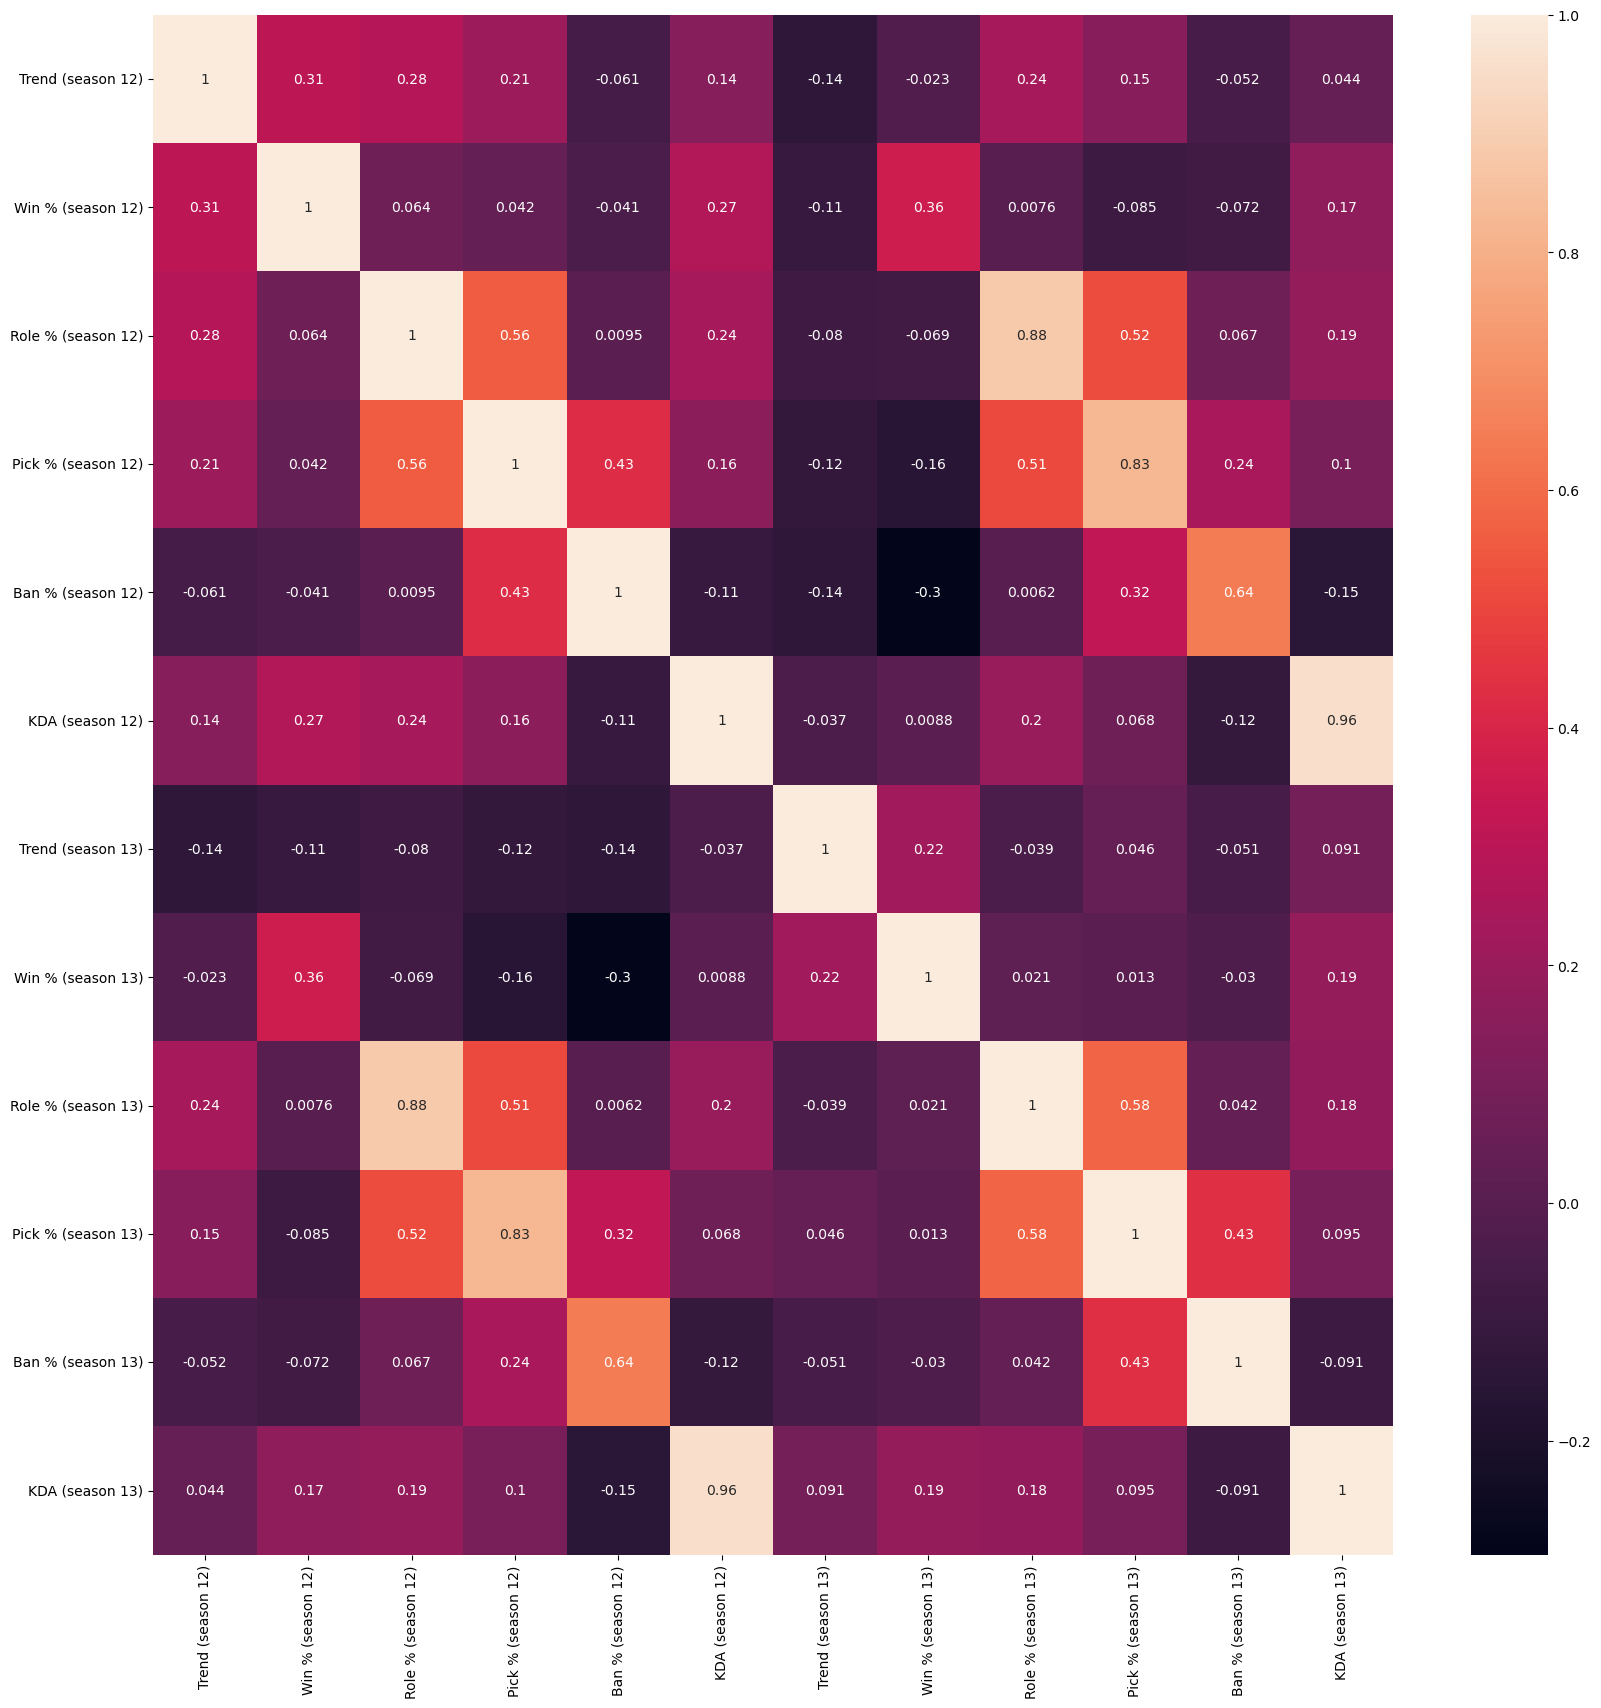

In [73]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

<Axes: >

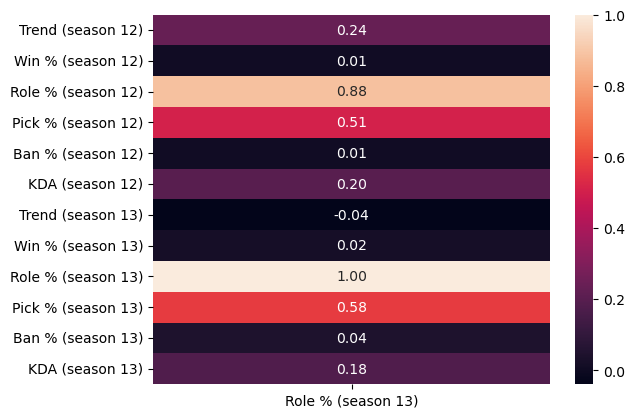

In [74]:
sns.heatmap(df.corr(numeric_only=True)[['Role % (season 13)']], annot=True, fmt='.2f')

In [75]:
len(df)

258

In [76]:
len(df['Role % (season 13)'].unique())

237

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import (
    MinMaxScaler,
    LabelEncoder,
    OrdinalEncoder,
)
import numpy as np

In [78]:
iterative_imputer=IterativeImputer()

In [79]:
imputed_data = iterative_imputer.fit_transform(df[['Role % (season 13)', 'Role % (season 12)','Pick % (season 12)','Pick % (season 13)'
                                                  ,'KDA (season 13)', 'KDA (season 12)']])

In [80]:
df[['Role % (season 13)', 'Role % (season 12)','Pick % (season 12)','Pick % (season 13)'
                                                ,'KDA (season 13)', 'KDA (season 12)']]=imputed_data

In [81]:
df.head()

,Name,Class (season 12),Role,Tier (season 12),Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Tier (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13)
0,Aatrox,Fighter,TOP,A,6.52,49.97,94.62,4.43,2.03,1.97,Fighter,S,-31.86,47.68,91.63,6.62,11.98,1.77
1,Ahri,Mage,MID,A,-0.24,49.93,93.47,4.62,1.04,2.56,Mage,S,4.55,49.50,94.65,5.81,1.73,2.58
2,Akali,Assassin,MID,S,6.51,48.59,65.65,8.16,12.88,2.34,Assassin,S,4.33,48.41,75.74,8.11,13.02,2.37
3,Akali,Assassin,TOP,A,3.34,48.57,34.06,4.24,12.88,2.04,Assassin,C,-1.51,45.92,23.50,2.55,13.02,2.00
4,Akshan,Marksman,MID,S,0.65,51.46,58.01,4.83,21.91,2.23,Marksman,A,0.34,51.62,66.03,2.75,3.79,2.26


In [82]:
df.isnull().sum()

Name                   0
Class (season 12)     27
Role                   0
Tier (season 12)      26
Trend (season 12)     26
Win % (season 12)     26
Role % (season 12)     0
Pick % (season 12)     0
Ban % (season 12)     26
KDA (season 12)        0
Class (season 13)     14
Tier (season 13)      14
Trend (season 13)     14
Win % (season 13)     14
Role % (season 13)     0
Pick % (season 13)     0
Ban % (season 13)     14
KDA (season 13)        0
dtype: int64

<Axes: xlabel='Class (season 12)'>

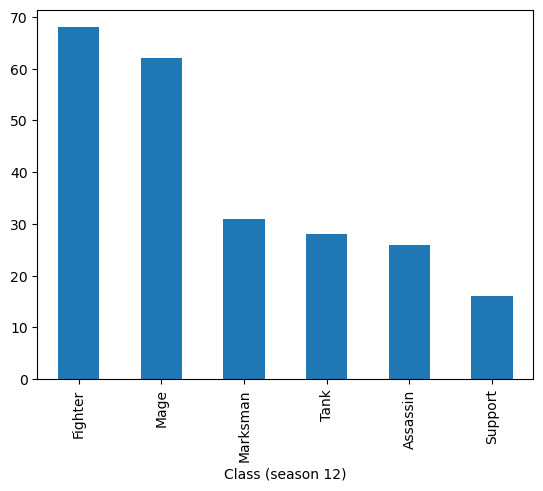

In [83]:
df['Class (season 12)'].value_counts().plot.bar()

In [84]:
label_encoder=LabelEncoder()
encoded=label_encoder.fit_transform(df['Class (season 12)'])

In [85]:
label_encoder.classes_

array(['Assassin', 'Fighter', 'Mage', 'Marksman', 'Support', 'Tank', nan],
      dtype=object)

In [91]:
df['Class (season 12)']=encoded
df.loc[df['Class (season 12)'] == 6, 'Class (season 12)'] = np.nan

In [92]:
encoded=label_encoder.transform(df['Class (season 13)'])
df['Class (season 13)']=encoded
df.loc[df['Class (season 13)'] == 6, 'Class (season 13)'] = np.nan

In [93]:
df.head()

,Name,Class (season 12),Role,Tier (season 12),Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Tier (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13)
0,Aatrox,1.0,TOP,A,6.52,49.97,94.62,4.43,2.03,1.97,1.0,S,-31.86,47.68,91.63,6.62,11.98,1.77
1,Ahri,2.0,MID,A,-0.24,49.93,93.47,4.62,1.04,2.56,2.0,S,4.55,49.50,94.65,5.81,1.73,2.58
2,Akali,0.0,MID,S,6.51,48.59,65.65,8.16,12.88,2.34,0.0,S,4.33,48.41,75.74,8.11,13.02,2.37
3,Akali,0.0,TOP,A,3.34,48.57,34.06,4.24,12.88,2.04,0.0,C,-1.51,45.92,23.50,2.55,13.02,2.00
4,Akshan,3.0,MID,S,0.65,51.46,58.01,4.83,21.91,2.23,3.0,A,0.34,51.62,66.03,2.75,3.79,2.26


<Axes: >

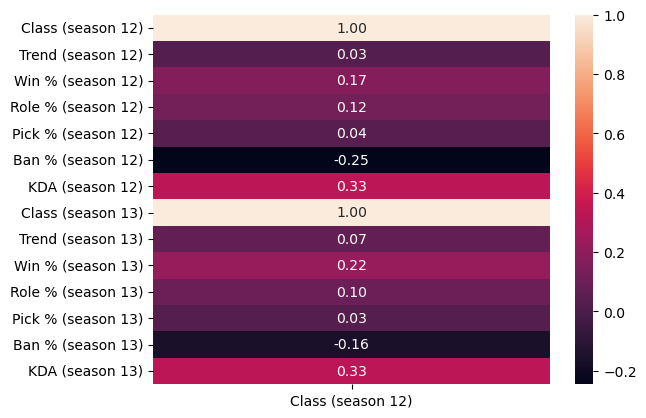

In [94]:
sns.heatmap(df.corr(numeric_only=True)[['Class (season 12)']], annot=True, fmt='.2f')

In [95]:
values1=df['Class (season 12)'].values.tolist()
values2=df['Class (season 13)'].values.tolist()

In [96]:
ctr=0
for i,val in enumerate(values1):
    if pd.isna(val) and pd.isna(values2[i]):
        ctr+=1
ctr

14

In [97]:
new_rows=[]
for _,row in df.iterrows():
    rew_cp=row.copy()
    if pd.isna(rew_cp['Class (season 12)']) and pd.isna(rew_cp['Class (season 13)']):
        continue
    else:
        if pd.isna(rew_cp['Class (season 12)']): rew_cp['Class (season 12)']=rew_cp['Class (season 13)']
        elif pd.isna(rew_cp['Class (season 13)']): rew_cp['Class (season 13)']=rew_cp['Class (season 12)']
    new_rows.append(rew_cp)

df = pd.DataFrame(new_rows)
            

In [98]:
df.head()

,Name,Class (season 12),Role,Tier (season 12),Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Tier (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13)
0,Aatrox,1.0,TOP,A,6.52,49.97,94.62,4.43,2.03,1.97,1.0,S,-31.86,47.68,91.63,6.62,11.98,1.77
1,Ahri,2.0,MID,A,-0.24,49.93,93.47,4.62,1.04,2.56,2.0,S,4.55,49.50,94.65,5.81,1.73,2.58
2,Akali,0.0,MID,S,6.51,48.59,65.65,8.16,12.88,2.34,0.0,S,4.33,48.41,75.74,8.11,13.02,2.37
3,Akali,0.0,TOP,A,3.34,48.57,34.06,4.24,12.88,2.04,0.0,C,-1.51,45.92,23.50,2.55,13.02,2.00
4,Akshan,3.0,MID,S,0.65,51.46,58.01,4.83,21.91,2.23,3.0,A,0.34,51.62,66.03,2.75,3.79,2.26


In [99]:
df.isnull().sum()

Name                   0
Class (season 12)      0
Role                   0
Tier (season 12)      26
Trend (season 12)     26
Win % (season 12)     26
Role % (season 12)     0
Pick % (season 12)     0
Ban % (season 12)     26
KDA (season 12)        0
Class (season 13)      0
Tier (season 13)       0
Trend (season 13)      0
Win % (season 13)      0
Role % (season 13)     0
Pick % (season 13)     0
Ban % (season 13)      0
KDA (season 13)        0
dtype: int64

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 257
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                244 non-null    object 
 1   Class (season 12)   244 non-null    float64
 2   Role                244 non-null    object 
 3   Tier (season 12)    218 non-null    object 
 4   Trend (season 12)   218 non-null    float64
 5   Win % (season 12)   218 non-null    float64
 6   Role % (season 12)  244 non-null    float64
 7   Pick % (season 12)  244 non-null    float64
 8   Ban % (season 12)   218 non-null    float64
 9   KDA (season 12)     244 non-null    float64
 10  Class (season 13)   244 non-null    float64
 11  Tier (season 13)    244 non-null    object 
 12  Trend (season 13)   244 non-null    float64
 13  Win % (season 13)   244 non-null    float64
 14  Role % (season 13)  244 non-null    float64
 15  Pick % (season 13)  244 non-null    float64
 16  Ban % (season

<Axes: >

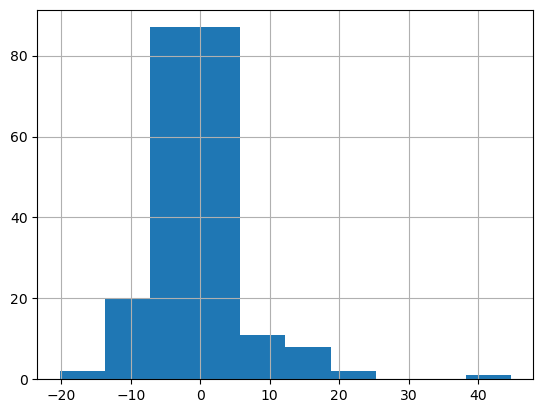

In [102]:
df['Trend (season 12)'].hist()

<Axes: >

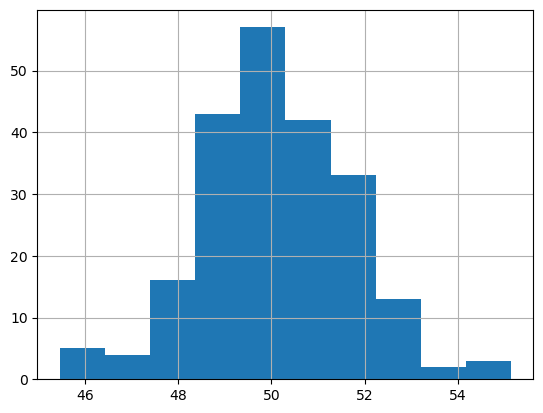

In [103]:
df['Win % (season 12)'].hist()

<Axes: >

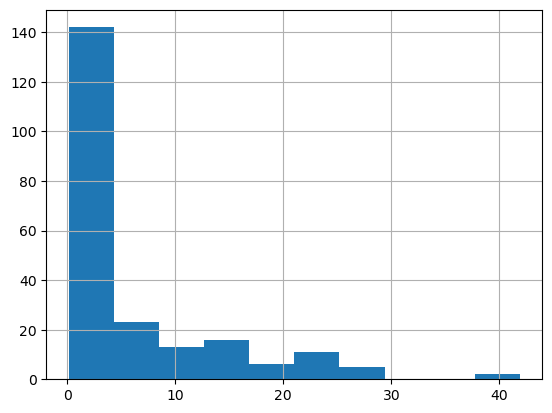

In [104]:
df['Ban % (season 12)'].hist()

In [107]:
simple_imputer=SimpleImputer(strategy='median')
df[['Ban % (season 12)']]=simple_imputer.fit_transform(df[['Ban % (season 12)']])

In [108]:
df[['Win % (season 12)']]=simple_imputer.fit_transform(df[['Win % (season 12)']])

In [110]:
df[['Trend (season 12)']]=simple_imputer.fit_transform(df[['Trend (season 12)']])

In [111]:
df.isnull().sum()

Name                   0
Class (season 12)      0
Role                   0
Tier (season 12)      26
Trend (season 12)      0
Win % (season 12)      0
Role % (season 12)     0
Pick % (season 12)     0
Ban % (season 12)      0
KDA (season 12)        0
Class (season 13)      0
Tier (season 13)       0
Trend (season 13)      0
Win % (season 13)      0
Role % (season 13)     0
Pick % (season 13)     0
Ban % (season 13)      0
KDA (season 13)        0
dtype: int64

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 257
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                244 non-null    object 
 1   Class (season 12)   244 non-null    float64
 2   Role                244 non-null    object 
 3   Tier (season 12)    218 non-null    object 
 4   Trend (season 12)   244 non-null    float64
 5   Win % (season 12)   244 non-null    float64
 6   Role % (season 12)  244 non-null    float64
 7   Pick % (season 12)  244 non-null    float64
 8   Ban % (season 12)   244 non-null    float64
 9   KDA (season 12)     244 non-null    float64
 10  Class (season 13)   244 non-null    float64
 11  Tier (season 13)    244 non-null    object 
 12  Trend (season 13)   244 non-null    float64
 13  Win % (season 13)   244 non-null    float64
 14  Role % (season 13)  244 non-null    float64
 15  Pick % (season 13)  244 non-null    float64
 16  Ban % (season

In [113]:
df.head()
    

,Name,Class (season 12),Role,Tier (season 12),Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Tier (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13)
0,Aatrox,1.0,TOP,A,6.52,49.97,94.62,4.43,2.03,1.97,1.0,S,-31.86,47.68,91.63,6.62,11.98,1.77
1,Ahri,2.0,MID,A,-0.24,49.93,93.47,4.62,1.04,2.56,2.0,S,4.55,49.50,94.65,5.81,1.73,2.58
2,Akali,0.0,MID,S,6.51,48.59,65.65,8.16,12.88,2.34,0.0,S,4.33,48.41,75.74,8.11,13.02,2.37
3,Akali,0.0,TOP,A,3.34,48.57,34.06,4.24,12.88,2.04,0.0,C,-1.51,45.92,23.50,2.55,13.02,2.00
4,Akshan,3.0,MID,S,0.65,51.46,58.01,4.83,21.91,2.23,3.0,A,0.34,51.62,66.03,2.75,3.79,2.26


In [117]:
targets=[]
for _,row in df.iterrows():
    val1=row['Tier (season 12)']
    val2=row['Tier (season 13)']
    clas=0
    if type(val1)==str and val1=='S+':clas=1
    elif type(val2)==str and val2 in ['S','S+']:clas=1
    targets.append(clas)
df["World Cup Suitable"] = targets
df.drop(columns=['Tier (season 12)','Tier (season 13)'],inplace=True)
        

In [118]:
df.head()

,Name,Class (season 12),Role,Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13),World Cup Suitable
0,Aatrox,1.0,TOP,6.52,49.97,94.62,4.43,2.03,1.97,1.0,-31.86,47.68,91.63,6.62,11.98,1.77,1
1,Ahri,2.0,MID,-0.24,49.93,93.47,4.62,1.04,2.56,2.0,4.55,49.50,94.65,5.81,1.73,2.58,1
2,Akali,0.0,MID,6.51,48.59,65.65,8.16,12.88,2.34,0.0,4.33,48.41,75.74,8.11,13.02,2.37,1
3,Akali,0.0,TOP,3.34,48.57,34.06,4.24,12.88,2.04,0.0,-1.51,45.92,23.50,2.55,13.02,2.00,0
4,Akshan,3.0,MID,0.65,51.46,58.01,4.83,21.91,2.23,3.0,0.34,51.62,66.03,2.75,3.79,2.26,0


In [119]:
df.isnull().sum()

Name                  0
Class (season 12)     0
Role                  0
Trend (season 12)     0
Win % (season 12)     0
Role % (season 12)    0
Pick % (season 12)    0
Ban % (season 12)     0
KDA (season 12)       0
Class (season 13)     0
Trend (season 13)     0
Win % (season 13)     0
Role % (season 13)    0
Pick % (season 13)    0
Ban % (season 13)     0
KDA (season 13)       0
World Cup Suitable    0
dtype: int64

In [120]:
len(df)

244

In [121]:
df.drop(columns=['Name'],inplace=True)

In [122]:
df.head()

,Class (season 12),Role,Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13),World Cup Suitable
0,1.0,TOP,6.52,49.97,94.62,4.43,2.03,1.97,1.0,-31.86,47.68,91.63,6.62,11.98,1.77,1
1,2.0,MID,-0.24,49.93,93.47,4.62,1.04,2.56,2.0,4.55,49.50,94.65,5.81,1.73,2.58,1
2,0.0,MID,6.51,48.59,65.65,8.16,12.88,2.34,0.0,4.33,48.41,75.74,8.11,13.02,2.37,1
3,0.0,TOP,3.34,48.57,34.06,4.24,12.88,2.04,0.0,-1.51,45.92,23.50,2.55,13.02,2.00,0
4,3.0,MID,0.65,51.46,58.01,4.83,21.91,2.23,3.0,0.34,51.62,66.03,2.75,3.79,2.26,0


In [123]:
df.Role.unique()

array(['TOP', 'MID', 'SUPPORT', 'JUNGLE', 'ADC'], dtype=object)

In [124]:
label_encoder = LabelEncoder()
df["Role"] = label_encoder.fit_transform(df["Role"])
df["Role"].value_counts()

Role
2    64
4    59
1    49
3    46
0    26
Name: count, dtype: int64

In [125]:
df['World Cup Suitable'].value_counts()

World Cup Suitable
0    180
1     64
Name: count, dtype: int64

In [126]:
negative=df[df['World Cup Suitable']==0].sample(64)
positive=df[df['World Cup Suitable']==1]

In [127]:
new_df=pd.concat([negative,positive]).sample(frac=1,random_state=42)

In [129]:
new_df.reset_index(drop=True)

,Class (season 12),Role,Trend (season 12),Win % (season 12),Role % (season 12),Pick % (season 12),Ban % (season 12),KDA (season 12),Class (season 13),Trend (season 13),Win % (season 13),Role % (season 13),Pick % (season 13),Ban % (season 13),KDA (season 13),World Cup Suitable
0,1.0,1,1.380,49.950,97.800000,9.7000,12.18,2.410000,1.0,-22.06,48.23,97.18,6.68,5.46,2.39,0
1,3.0,0,-0.685,49.925,94.276628,6.9567,2.41,2.462226,3.0,-14.49,49.84,95.18,6.55,2.45,2.49,0
2,3.0,0,-9.950,49.660,93.400000,6.0300,1.11,2.320000,3.0,-4.93,50.27,42.22,6.49,6.03,2.43,0
3,2.0,2,3.770,52.580,11.760000,0.4100,3.30,2.190000,2.0,-8.67,49.37,12.72,0.37,1.67,2.28,0
4,1.0,4,14.480,49.820,87.430000,5.3100,5.99,1.790000,1.0,-20.57,50.23,70.18,6.82,14.83,1.88,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,0.0,1,3.870,51.660,82.670000,5.9800,17.16,2.750000,0.0,-9.54,49.55,80.48,5.75,15.81,2.78,1
124,0.0,2,2.170,51.040,58.680000,4.7300,13.69,2.140000,0.0,-0.52,48.10,81.80,2.62,0.94,2.09,0
125,1.0,1,0.280,48.450,96.610000,15.2900,16.26,2.820000,1.0,-7.81,47.13,92.08,9.54,4.07,2.66,1
126,5.0,3,2.550,50.090,14.950000,0.4400,1.64,2.050000,5.0,1.09,52.39,50.05,4.09,5.20,2.18,0


In [130]:
df=new_df

In [131]:
df['World Cup Suitable'].value_counts()

World Cup Suitable
0    64
1    64
Name: count, dtype: int64

In [136]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [139]:
model=RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)

In [137]:
X_train, X_test, Y_train, Y_test = train_test_split(df.drop(columns=['World Cup Suitable']), df['World Cup Suitable'],test_size=0.2)

In [140]:
model.fit(X_train,Y_train)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [142]:
y_pred = model.predict(X_test)

In [144]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
)

In [145]:
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

[[ 9  3]
 [ 2 12]]
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        12
           1       0.80      0.86      0.83        14

    accuracy                           0.81        26
   macro avg       0.81      0.80      0.81        26
weighted avg       0.81      0.81      0.81        26

